In [1]:
import cv2
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# ============================================================
# SETTINGS
# ============================================================

DATA_PATH = r"C:\Users\PC-LAB1\Desktop\shok\mnist\mnist_train.csv"


# ============================================================
# READ CSV
# ============================================================

df = pd.read_csv(DATA_PATH)

print("Number of images:", len(df))
print("Number of columns:", len(df.columns))


# ============================================================
# SEPARATE LABELS AND PIXELS
# ============================================================

y = df["label"].values

X_pixels = df.drop(
    "label",
    axis=1
).values


print("\nOriginal data")
print("-------------")
print("Images:", X_pixels.shape[0])
print("Pixels per image:", X_pixels.shape[1])


# ============================================================
# HU MOMENTS FEATURE EXTRACTION
# ============================================================

X = []

for pixels in X_pixels:

    # Convert 784 pixels to 28x28 image
    image = pixels.reshape(28, 28).astype(
        np.uint8
    )

    # Calculate image moments
    moments = cv2.moments(image)

    # Calculate Hu Moments
    hu = cv2.HuMoments(
        moments
    ).flatten()

    # Log transform for better numerical scale
    hu = -np.sign(hu) * np.log10(
        np.abs(hu) + 1e-30
    )

    X.append(hu)


X = np.array(X)


# ============================================================
# FEATURE INFORMATION
# ============================================================

print("\nHu Moments")
print("----------")

print(
    "Number of features:",
    X.shape[1]
)

print(
    "Feature matrix shape:",
    X.shape
)

print(
    "First image features:",
    X[0]
)

print(
    "First 20 features:",
    X[0][:20]
)


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("\nTrain/Test split")
print("----------------")

print(
    "Training images:",
    len(X_train)
)

print(
    "Testing images:",
    len(X_test)
)


# ============================================================
# STANDARD SCALER
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)


# ============================================================
# SVM
# ============================================================

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)


# ============================================================
# TRAIN
# ============================================================

print("\nTraining SVM...")
print("--------------")

svm.fit(
    X_train,
    y_train
)


# ============================================================
# PREDICTION
# ============================================================

y_pred = svm.predict(
    X_test
)


# ============================================================
# EVALUATION
# ============================================================

print("\nAccuracy")
print("--------")

print(
    accuracy_score(
        y_test,
        y_pred
    )
)


print("\nConfusion Matrix")
print("----------------")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


print("\nClassification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Number of images: 60000
Number of columns: 785

Original data
-------------
Images: 60000
Pixels per image: 784

Hu Moments
----------
Number of features: 7
Feature matrix shape: (60000, 7)
First image features: [  2.67132496   5.83949722   9.2393031    9.89011559  19.89598154
  13.35776927 -19.48534639]
First 20 features: [  2.67132496   5.83949722   9.2393031    9.89011559  19.89598154
  13.35776927 -19.48534639]

Train/Test split
----------------
Training images: 48000
Testing images: 12000

Training SVM...
--------------

Accuracy
--------
0.59625

Confusion Matrix
----------------
[[ 922    3   11   27   16   67    5    0  134    0]
 [   1 1297    5   10    2    3    0    4   21    5]
 [  57    4  431   82  289   90    5   52  114   68]
 [  45    7   98  739   10  112   79   11  109   16]
 [  69    1  170   32  596   18   23   49   77  133]
 [ 178    2  111  175   37  274   54   82  124   47]
 [   7    0   28   61   29   19  873   56    7  104]
 [   2    5   66   31   52   23   59

In [2]:
import cv2
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# SETTINGS
# ============================================================

DATA_PATH = r"C:\Users\PC-LAB1\Desktop\shok\mnist\mnist_train.csv"


# ============================================================
# READ CSV
# ============================================================

df = pd.read_csv(DATA_PATH)

print("Number of images:", len(df))
print("Number of columns:", len(df.columns))


# ============================================================
# SEPARATE LABELS AND PIXELS
# ============================================================

y = df["label"].values

X_pixels = df.drop(
    "label",
    axis=1
).values

print("\nOriginal data")
print("-------------")
print("Images:", X_pixels.shape[0])
print("Pixels per image:", X_pixels.shape[1])


# ============================================================
# HU MOMENTS FEATURE EXTRACTION
# ============================================================

X = []

for pixels in X_pixels:

    # Convert 784 pixels to 28x28
    image = pixels.reshape(28, 28).astype(np.uint8)

    # --------------------------------------------------------
    # Binary threshold using Otsu
    # --------------------------------------------------------

    _, binary = cv2.threshold(
        image,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # --------------------------------------------------------
    # Calculate image moments
    # --------------------------------------------------------

    moments = cv2.moments(binary)

    # --------------------------------------------------------
    # Calculate 7 Hu Moments
    # --------------------------------------------------------

    hu = cv2.HuMoments(
        moments
    ).flatten()

    # --------------------------------------------------------
    # Log transform
    # Makes very small Hu values easier for SVM to handle
    # --------------------------------------------------------

    hu = -np.sign(hu) * np.log10(
        np.abs(hu) + 1e-30
    )

    X.append(hu)


X = np.array(X)


# ============================================================
# FEATURE INFORMATION
# ============================================================

print("\nHu Moments")
print("----------")

print(
    "Number of features:",
    X.shape[1]
)

print(
    "Feature matrix shape:",
    X.shape
)

print(
    "First image features:",
    X[0]
)

print(
    "First 20 features:",
    X[0][:20]
)


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain/Test split")
print("----------------")

print(
    "Training images:",
    len(X_train)
)

print(
    "Testing images:",
    len(X_test)
)


# ============================================================
# STANDARD SCALER
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)


# ============================================================
# SVM
# ============================================================

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)


# ============================================================
# TRAIN
# ============================================================

print("\nTraining SVM...")
print("--------------")

svm.fit(
    X_train,
    y_train
)


# ============================================================
# PREDICTION
# ============================================================

y_pred = svm.predict(
    X_test
)


# ============================================================
# EVALUATION
# ============================================================

print("\nAccuracy")
print("--------")

print(
    accuracy_score(
        y_test,
        y_pred
    )
)


print("\nConfusion Matrix")
print("----------------")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


print("\nClassification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Number of images: 60000
Number of columns: 785

Original data
-------------
Images: 60000
Pixels per image: 784

Hu Moments
----------
Number of features: 7
Feature matrix shape: (60000, 7)
First image features: [  2.69045173   5.83852631   9.34204146  10.04339018  20.32703363
  13.77987216 -19.75088322]
First 20 features: [  2.69045173   5.83852631   9.34204146  10.04339018  20.32703363
  13.77987216 -19.75088322]

Train/Test split
----------------
Training images: 48000
Testing images: 12000

Training SVM...
--------------

Accuracy
--------
0.5963333333333334

Confusion Matrix
----------------
[[ 929    3   13   29   14   58    4    0  133    2]
 [   0 1293    8   11    2    4    0    4   20    6]
 [  62    2  418   91  284   90    5   47  117   76]
 [  39    9   97  738    9  112   71   15  117   19]
 [  74    1  164   30  567   17   19   56   84  156]
 [ 187    3   98  185   35  278   54   85  114   45]
 [   6    0   18   70   39   18  850   56   11  116]
 [   3    6   58   34   5

In [3]:
import cv2
import numpy as np
import pandas as pd

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# SETTINGS
# ============================================================

DATA_PATH = r"C:\Users\PC-LAB1\Desktop\shok\mnist\mnist_train.csv"


# ============================================================
# READ CSV
# ============================================================

df = pd.read_csv(DATA_PATH)

print("Number of images:", len(df))
print("Number of columns:", len(df.columns))


# ============================================================
# SEPARATE LABELS AND PIXELS
# ============================================================

y = df["label"].values

X_pixels = df.drop(
    "label",
    axis=1
).values

print("\nOriginal data")
print("-------------")
print("Images:", X_pixels.shape[0])
print("Pixels per image:", X_pixels.shape[1])


# ============================================================
# HOG FEATURE EXTRACTION
# ============================================================

X = []

print("\nExtracting HOG features...")
print("--------------------------")

for i, pixels in enumerate(X_pixels):

    # Convert 784 pixels to 28x28 image
    image = pixels.reshape(
        28,
        28
    ).astype(np.uint8)

    # HOG features
    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    X.append(features)

    if (i + 1) % 5000 == 0:
        print(
            "Processed:",
            i + 1,
            "/",
            len(X_pixels)
        )


X = np.array(X)


# ============================================================
# FEATURE INFORMATION
# ============================================================

print("\nHOG Feature Information")
print("-----------------------")

print(
    "Number of features:",
    X.shape[1]
)

print(
    "Feature matrix shape:",
    X.shape
)

print(
    "First 20 features:",
    X[0][:20]
)


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain/Test split")
print("----------------")

print(
    "Training images:",
    len(X_train)
)

print(
    "Testing images:",
    len(X_test)
)


# ============================================================
# STANDARD SCALER
# ============================================================

print("\nScaling features...")
print("-------------------")

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)


# ============================================================
# SVM
# ============================================================

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)


# ============================================================
# TRAIN
# ============================================================

print("\nTraining SVM...")
print("--------------")

svm.fit(
    X_train,
    y_train
)


# ============================================================
# PREDICTION
# ============================================================

y_pred = svm.predict(
    X_test
)


# ============================================================
# EVALUATION
# ============================================================

print("\nAccuracy")
print("--------")

print(
    accuracy_score(
        y_test,
        y_pred
    )
)


print("\nConfusion Matrix")
print("----------------")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


print("\nClassification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Number of images: 60000
Number of columns: 785

Original data
-------------
Images: 60000
Pixels per image: 784

Extracting HOG features...
--------------------------
Processed: 5000 / 60000
Processed: 10000 / 60000
Processed: 15000 / 60000
Processed: 20000 / 60000
Processed: 25000 / 60000
Processed: 30000 / 60000
Processed: 35000 / 60000
Processed: 40000 / 60000
Processed: 45000 / 60000
Processed: 50000 / 60000
Processed: 55000 / 60000
Processed: 60000 / 60000

HOG Feature Information
-----------------------
Number of features: 1296
Feature matrix shape: (60000, 1296)
First 20 features: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Train/Test split
----------------
Training images: 48000
Testing images: 12000

Scaling features...
-------------------

Training SVM...
--------------

Accuracy
--------
0.9834166666666667

Confusion Matrix
----------------
[[1180    1    0    0    0    0    3    1    0    0]
 [   0 1334    4    2    0    0    0    5    3    0]
 [   0    4

In [4]:
import cv2
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# SETTINGS
# ============================================================

DATA_PATH = r"C:\Users\PC-LAB1\Desktop\shok\mnist\mnist_train.csv"


# ============================================================
# READ CSV
# ============================================================

df = pd.read_csv(DATA_PATH)

print("Number of images:", len(df))
print("Number of columns:", len(df.columns))


# ============================================================
# SEPARATE LABELS AND PIXELS
# ============================================================

y = df["label"].values

X = df.drop(
    "label",
    axis=1
).values.astype(np.float32)


# ============================================================
# FEATURE INFORMATION
# ============================================================

print("\nRaw Pixel Features")
print("------------------")

print("Images:", X.shape[0])
print("Features per image:", X.shape[1])
print("Feature matrix shape:", X.shape)

print("\nFirst 20 features:")
print(X[0][:20])


# ============================================================
# NORMALIZE PIXEL VALUES
# ============================================================

X = X / 255.0


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain/Test split")
print("----------------")

print("Training images:", len(X_train))
print("Testing images:", len(X_test))


# ============================================================
# STANDARD SCALER
# ============================================================

print("\nScaling features...")
print("-------------------")

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# ============================================================
# SVM
# ============================================================

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)


# ============================================================
# TRAIN
# ============================================================

print("\nTraining SVM...")
print("--------------")

svm.fit(
    X_train,
    y_train
)


# ============================================================
# PREDICTION
# ============================================================

y_pred = svm.predict(
    X_test
)


# ============================================================
# EVALUATION
# ============================================================

print("\nAccuracy")
print("--------")

print(
    accuracy_score(
        y_test,
        y_pred
    )
)


print("\nConfusion Matrix")
print("----------------")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


print("\nClassification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Number of images: 60000
Number of columns: 785

Raw Pixel Features
------------------
Images: 60000
Features per image: 784
Feature matrix shape: (60000, 784)

First 20 features:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Train/Test split
----------------
Training images: 48000
Testing images: 12000

Scaling features...
-------------------

Training SVM...
--------------

Accuracy
--------
0.972

Confusion Matrix
----------------
[[1178    1    0    0    0    1    2    1    1    1]
 [   0 1333    8    2    2    0    0    3    0    0]
 [   4    4 1162    7    1    0    4    6    3    1]
 [   2    0   13 1171    0   11    0   13   13    3]
 [   4    4   10    1 1130    2    4    5    1    7]
 [   3    1    0    8    3 1053   10    3    3    0]
 [   7    2    2    0    4    6 1151   10    2    0]
 [   0    6   10    3    4    0    0 1217    2   11]
 [   3    5    8    6    2    9    2    3 1127    5]
 [   3    4    0    3    5    3    0   23    7 1142]]

Classification

Test images: 10000
Features per image: 784


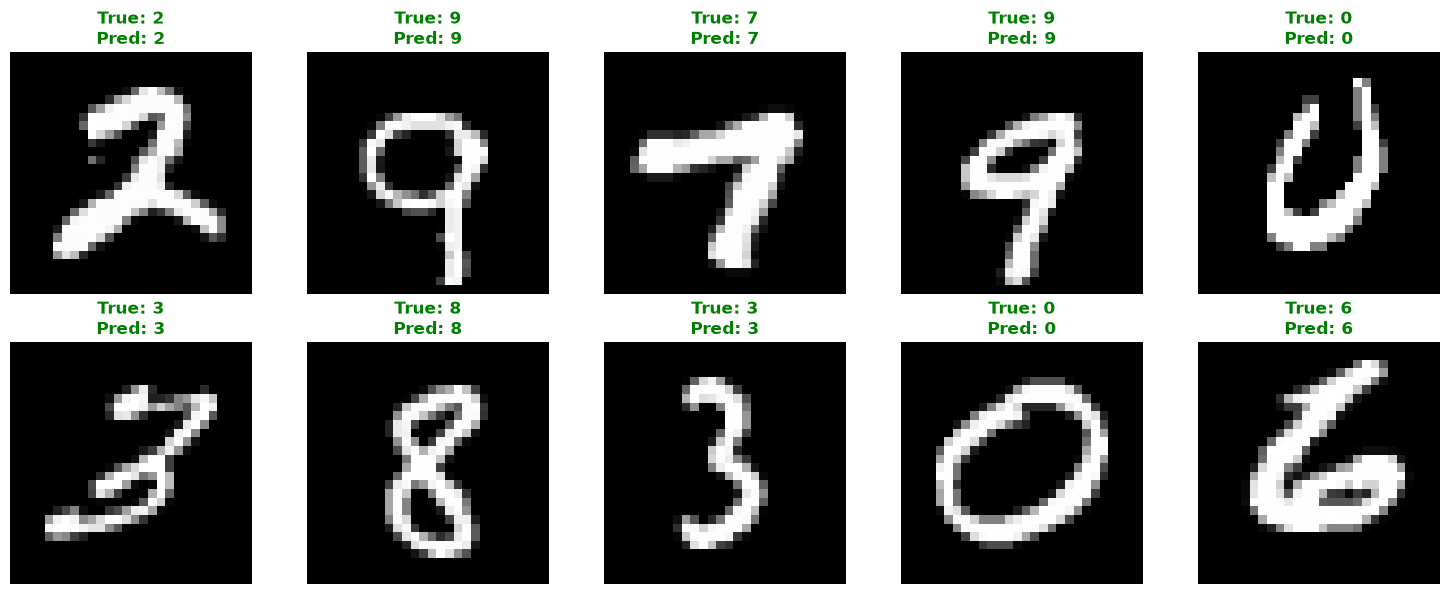


Predictions
-----------
Image 1: True = 2, Predicted = 2 -> CORRECT
Image 2: True = 9, Predicted = 9 -> CORRECT
Image 3: True = 7, Predicted = 7 -> CORRECT
Image 4: True = 9, Predicted = 9 -> CORRECT
Image 5: True = 0, Predicted = 0 -> CORRECT
Image 6: True = 3, Predicted = 3 -> CORRECT
Image 7: True = 8, Predicted = 8 -> CORRECT
Image 8: True = 3, Predicted = 3 -> CORRECT
Image 9: True = 0, Predicted = 0 -> CORRECT
Image 10: True = 6, Predicted = 6 -> CORRECT


In [22]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

TEST_PATH = r"C:\Users\PC-LAB1\Desktop\shok\mnist\mnist_test.csv"

NUMBER_OF_IMAGES = 10


# ============================================================
# LOAD TEST DATA
# ============================================================

df_test = pd.read_csv(TEST_PATH)

y_test = df_test["label"].values

X_test = df_test.drop(
    "label",
    axis=1
).values.astype(np.float32)

print("Test images:", len(X_test))
print("Features per image:", X_test.shape[1])


# ============================================================
# PREPARE PIXELS
# ============================================================

X_test_scaled = X_test / 255.0

X_test_scaled = scaler.transform(
    X_test_scaled
)


# ============================================================
# RANDOM IMAGES
# ============================================================



random_indices = np.random.choice(
    len(X_test),
    NUMBER_OF_IMAGES,
    replace=False
)


X_selected = X_test_scaled[random_indices]

y_true = y_test[random_indices]


# ============================================================
# PREDICT
# ============================================================

y_pred = svm.predict(
    X_selected
)


# ============================================================
# DISPLAY
# ============================================================

plt.figure(figsize=(15, 6))

for i in range(NUMBER_OF_IMAGES):

    index = random_indices[i]

    image = X_test[index].reshape(
        28,
        28
    )

    correct = y_true[i] == y_pred[i]

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        image,
        cmap="gray"
    )

    if correct:
        title_color = "green"
    else:
        title_color = "red"

    plt.title(
        f"True: {y_true[i]}\n"
        f"Pred: {y_pred[i]}",
        color=title_color,
        fontweight="bold"
    )

    plt.axis("off")


plt.tight_layout()
plt.show()


# ============================================================
# PRINT RESULTS
# ============================================================

print("\nPredictions")
print("-----------")

for i in range(NUMBER_OF_IMAGES):

    if y_true[i] == y_pred[i]:
        result = "CORRECT"
    else:
        result = "WRONG"

    print(
        f"Image {i + 1}: "
        f"True = {y_true[i]}, "
        f"Predicted = {y_pred[i]} "
        f"-> {result}"
    )

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# ============================================================
# SETTINGS
# ============================================================

CSV_PATH = r"C:\Users\PC-LAB1\Desktop\shok\mnist\mnist_train.csv"

PCA_VARIANCE = 0.95


# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(CSV_PATH)

y = df["label"].values
X = df.drop("label", axis=1).values.astype(np.float32)

print("Number of images:", len(X))
print("Original features:", X.shape[1])


# ============================================================
# NORMALIZE PIXELS
# ============================================================

X = X / 255.0


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain/Test split")
print("----------------")
print("Training images:", len(X_train))
print("Testing images:", len(X_test))


# ============================================================
# STANDARD SCALER
# ============================================================

print("\nScaling features...")
print("-------------------")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================================
# PCA
# ============================================================

print("\nApplying PCA...")
print("--------------")

pca = PCA(
    n_components=PCA_VARIANCE,
    random_state=42
)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X_train.shape[1])
print("PCA features:", X_train_pca.shape[1])
print(
    "Explained variance:",
    pca.explained_variance_ratio_.sum()
)


# ============================================================
# SVM
# ============================================================

print("\nTraining SVM...")
print("--------------")

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

svm.fit(
    X_train_pca,
    y_train
)


# ============================================================
# PREDICTION
# ============================================================

y_pred = svm.predict(X_test_pca)


# ============================================================
# RESULTS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy")
print("--------")
print(accuracy)

print("\nConfusion Matrix")
print("----------------")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print("---------------------")
print(classification_report(y_test, y_pred))

Number of images: 60000
Original features: 784

Train/Test split
----------------
Training images: 48000
Testing images: 12000

Scaling features...
-------------------

Applying PCA...
--------------
Original features: 784
PCA features: 325
Explained variance: 0.9502091

Training SVM...
--------------

Accuracy
--------
0.9738333333333333

Confusion Matrix
----------------
[[1178    1    1    0    0    0    2    1    1    1]
 [   0 1333    8    2    2    0    0    3    0    0]
 [   4    2 1165    7    1    0    4    5    3    1]
 [   3    0   13 1176    0    8    0   12   11    3]
 [   2    3   10    1 1132    2    3    5    0   10]
 [   3    0    0    8    3 1052    9    3    4    2]
 [   6    2    1    0    4    8 1151   10    2    0]
 [   1    4   10    4    1    0    0 1222    0   11]
 [   3    6    8    4    2    8    3    3 1130    3]
 [   3    3    0    3    5    2    0   20    7 1147]]

Classification Report
---------------------
              precision    recall  f1-score   su

Original image size: (405, 350)
Raw pixel features: 784
PCA features: 325


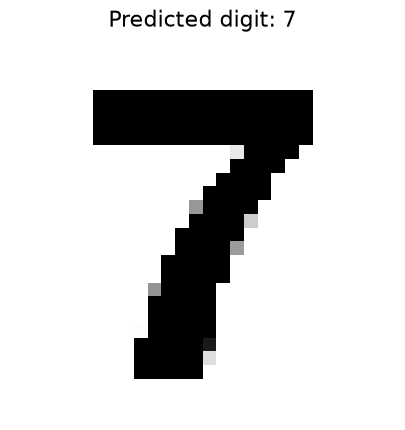


Predicted digit: 7


In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# IMAGE PATH
# ============================================================

IMAGE_PATH = r"\\192.168.1.10\shear all\day5\dc7_hi_3.gif"


# ============================================================
# LOAD IMAGE
# ============================================================

image = cv2.imread(
    IMAGE_PATH,
    cv2.IMREAD_GRAYSCALE
)

if image is None:
    print("Error: Could not load image.")
else:

    print("Original image size:", image.shape)


    # ========================================================
    # RESIZE TO 28x28
    # ========================================================

    image_28 = cv2.resize(
        image,
        (28, 28)
    )


    # ========================================================
    # RAW PIXELS
    # ========================================================

    features = image_28.astype(
        np.float32
    ).flatten()

    features = features / 255.0

    print("Raw pixel features:", len(features))


    # ========================================================
    # SCALE
    # ========================================================

    features_scaled = scaler.transform(
        features.reshape(1, -1)
    )


    # ========================================================
    # PCA
    # ========================================================

    features_pca = pca.transform(
        features_scaled
    )

    print("PCA features:", features_pca.shape[1])


    # ========================================================
    # PREDICTION
    # ========================================================

    prediction = svm.predict(
        features_pca
    )[0]


    # ========================================================
    # DISPLAY
    # ========================================================

    plt.figure(figsize=(5, 5))

    plt.imshow(
        image_28,
        cmap="gray"
    )

    plt.title(
        f"Predicted digit: {prediction}",
        fontsize=16
    )

    plt.axis("off")

    plt.show()


    print("\nPredicted digit:", prediction)

Test images: 10000
Features per image: 784
PCA features: 325


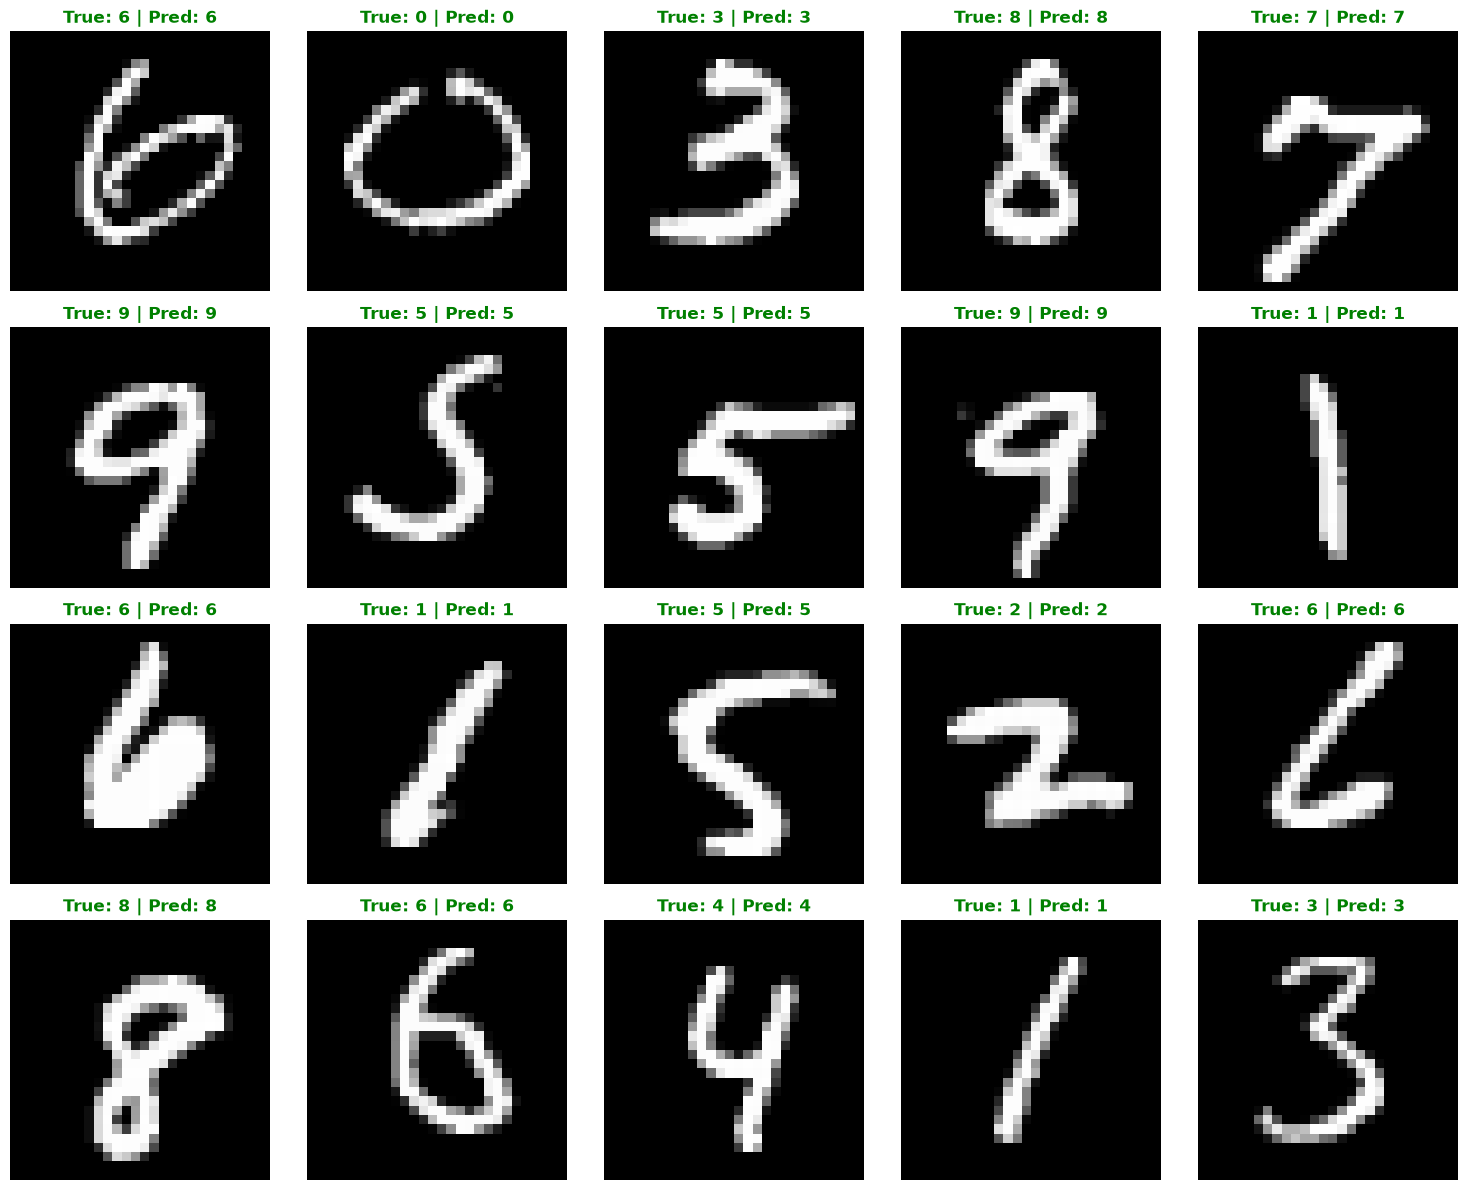


Results
-------
Images tested: 20
Correct: 20
Wrong: 0
Accuracy: 100.00%


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

TEST_PATH = r"C:\Users\PC-LAB1\Desktop\shok\mnist\mnist_test.csv"

NUMBER_OF_IMAGES = 20    # Change this to any number you want


# ============================================================
# LOAD TEST DATA
# ============================================================

df_test = pd.read_csv(TEST_PATH)

y_test = df_test["label"].values

X_test = df_test.drop(
    "label",
    axis=1
).values.astype(np.float32)

print("Test images:", len(X_test))
print("Features per image:", X_test.shape[1])


# ============================================================
# RAW PIXELS
# ============================================================

X_test = X_test / 255.0


# ============================================================
# SCALER
# ============================================================

X_test_scaled = scaler.transform(X_test)


# ============================================================
# PCA
# ============================================================

X_test_pca = pca.transform(X_test_scaled)

print("PCA features:", X_test_pca.shape[1])


# ============================================================
# RANDOM IMAGES
# ============================================================

if NUMBER_OF_IMAGES > len(X_test):
    NUMBER_OF_IMAGES = len(X_test)

random_indices = np.random.choice(
    len(X_test),
    NUMBER_OF_IMAGES,
    replace=False
)

X_selected = X_test_pca[random_indices]
y_true = y_test[random_indices]


# ============================================================
# PREDICT
# ============================================================

y_pred = svm.predict(X_selected)


# ============================================================
# DISPLAY
# ============================================================

cols = 5
rows = int(np.ceil(NUMBER_OF_IMAGES / cols))

plt.figure(figsize=(15, rows * 3))

for i in range(NUMBER_OF_IMAGES):

    index = random_indices[i]

    image = X_test[index].reshape(28, 28)

    correct = y_true[i] == y_pred[i]

    plt.subplot(rows, cols, i + 1)

    plt.imshow(
        image,
        cmap="gray"
    )

    label_color = "green" if correct else "red"

    plt.title(
        f"True: {y_true[i]} | Pred: {y_pred[i]}",
        color=label_color,
        fontweight="bold"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# RESULTS
# ============================================================

correct_count = np.sum(y_true == y_pred)

print("\nResults")
print("-------")
print("Images tested:", NUMBER_OF_IMAGES)
print("Correct:", correct_count)
print("Wrong:", NUMBER_OF_IMAGES - correct_count)
print(
    "Accuracy:",
    f"{correct_count / NUMBER_OF_IMAGES:.2%}"
)